## **Modelagem: XGBoost**

Neste notebook vamos construir e testar um modelo de classificação XGBoost para prever os funcionários que pedirão demissão voluntária.

O XGBoost será nosso terceiro modelo e vamos compará-lo com a regressão logística e o Random Forest.

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos de regressão diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 

## Importação de Bibliotecas

Nesta etapa são importadas todas as bibliotecas necessárias para **pré-processamento, modelagem e busca de hiperparâmetros**:

1. **Bibliotecas gerais**
   - `numpy` e `pandas`: manipulação de arrays e DataFrames.  
   - `matplotlib.pyplot`: geração de gráficos.  
   - `joblib`: salvar e carregar objetos treinados (como modelos e pipelines).

2. **Transformadores (scikit-learn)**
   - `ColumnTransformer`: aplica diferentes transformações a grupos de colunas.  
   - `OneHotEncoder`, `OrdinalEncoder`, `StandardScaler`, `TargetEncoder`: transformações para variáveis categóricas, ordinais e numéricas.  
   - `PolynomialFeatures`: cria novas features polinomiais a partir das originais.  
   - `KNNImputer`: imputação de valores ausentes com base nos vizinhos mais próximos.  
   - `Pipeline`: encadeia as etapas de pré-processamento e modelagem.

3. **Modelos**
   - `LogisticRegression`: modelo estatístico base usado para classificação.

4. **Busca de hiperparâmetros**
   - `loguniform`, `uniform`: distribuições de probabilidade usadas para amostragem de hiperparâmetros.  
   - `RandomizedSearchCV`: busca aleatória sobre o espaço de hiperparâmetros, combinando treino e validação cruzada.

---

👉 Essas importações organizam as ferramentas que serão usadas para **construir, ajustar e otimizar** o pipeline de machine learning.


In [9]:
### Libs padrão ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### Modelos ###
from xgboost import XGBClassifier
from category_encoders.target_encoder import TargetEncoder


### Pré-processamento ###
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder
from sklearn.pipeline import Pipeline

### Validação e busca ###
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform


## Carregamento dos Dados de Treino

Neste passo, os arquivos de treino previamente salvos em **CSV** são carregados para o ambiente:

1. **`X_train.csv`**  
   - Contém as variáveis preditoras (features) já separadas para treino.  
   - É lido em um DataFrame `X_train`.

2. **`y_train.csv`**  
   - Contém apenas a variável alvo (target), indicando o desfecho que se deseja prever.  
   - É lido em um DataFrame `y_train`.

---

👉 Esses arquivos foram gerados anteriormente no processo de preparação dos dados (divisão treino/teste) e agora serão usados como entrada para o pipeline de modelagem.


In [2]:
### dados ###
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()  # Converte para array 1D

## Definição dos Grupos de Variáveis

Neste trecho, organizamos todas as colunas do dataset em **grupos de variáveis** de acordo com sua natureza.  
Essa separação facilita o pré-processamento, pois cada tipo de variável exige um tratamento diferente no pipeline.

### Grupos criados:

- **Binárias (`binarias`)**  
  Variáveis com apenas duas categorias possíveis (ex.: *sim/não*, *masculino/feminino*).  
  Exemplos: `catl_sexo`, `catl_doenca_cronica`, `catl_cigarro`.

- **Numéricas (`numericas`)**  
  Variáveis quantitativas contínuas ou discretas que já estão em formato numérico.  
  Exemplos: `num_idade`, `num_idade_diagnostico`, `num_consultas`.

- **Ordinais (`ordinais`)**  
  Variáveis categóricas que possuem **ordem natural** entre as categorias (ex.: níveis de saúde ou de cobertura).  
  Exemplos: `ord_saude`, `ord_limita_asma`, `ord_nivel_plano`.

- **Categóricas (`categoricas`)**  
  Variáveis qualitativas **sem ordem definida** entre as categorias.  
  Exemplos: `catl_cor_raca`, `catl_tipo_de_area`, `cath_material_parede`.

---

👉 Essa estrutura (`tipos_variaveis1`) será usada no **ColumnTransformer** do pipeline para aplicar transformações específicas em cada grupo de variáveis.


In [3]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_crise_asma","catl_remedio_asma","catl_aerossol_asma",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos",
        "num_idade_diagnostico","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_limita_asma","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


### 🗂️ Definição dos grupos de variáveis

Antes de aplicar o pré-processamento, organizamos as variáveis do dataset em grupos, de acordo com sua natureza.  
Essa separação é importante porque cada tipo de variável requer um tratamento específico (imputação, codificação, escalonamento etc.).

- **Binárias (`binarias`)**: variáveis categóricas com apenas duas categorias possíveis (ex.: `catl_sexo`, `catl_doenca_cronica`).
- **Numéricas (`numericas`)**: variáveis quantitativas contínuas ou discretas (ex.: `num_idade`, `num_consultas`).
- **Ordinais (`ordinais`)**: variáveis categóricas que possuem uma ordem natural entre os valores (ex.: `ord_saude`, `ord_remedio_semana`).
- **Categóricas (`categoricas`)**: variáveis qualitativas sem ordem definida (ex.: `catl_cor_raca`, `cath_fonte_de_agua`).
- **Alta cardinalidade (`alta_cardinalidade`)**: variáveis categóricas com grande número de categorias distintas, que serão tratadas com `TargetEncoder` (ex.: `cath_trabalho`, `cath_destino_do_esgoto`).

Esses grupos são usados no `ColumnTransformer` para garantir que cada tipo de dado receba o pré-processamento adequado.


In [4]:
# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn<1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])



pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
    # IMPORTANTE: não force esparso aqui; deixe o CT decidir
    # sparse_threshold=0.3  # (padrão). Pode omitir.
)

## **Modelo**

In [5]:
model = XGBClassifier(n_estimators=500)

In [14]:
# 1) Pipeline: pré-processamento + XGB
pipeline = Pipeline([
    ("pre", pre),
    ("clf", XGBClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        tree_method="hist", device="cuda", 
        eval_metric="aucpr", #dataset desbalanceado
    ))
])


In [15]:
param_distributions = {
    'clf__learning_rate': loguniform(0.01, 0.2),
    'clf__max_depth': randint(2, 5),
    'clf__subsample': uniform(0.7, 0.2),
    'clf__colsample_bytree': uniform(0.7, 0.2),
    'clf__gamma': uniform(0, 0.3),
    'clf__reg_alpha': loguniform(1e-3, 1),
    'clf__reg_lambda': loguniform(1e-2, 10),
    'clf__min_child_weight': randint(1, 6)
}


In [16]:
random_search = RandomizedSearchCV(
    estimator=pipeline,                        # nosso pipeline (já tem o XGBClassifier com GPU dentro)
    param_distributions=param_distributions,   # grade de hiperparâmetros
    n_iter=50,                                 # número máximo de modelos a tentar
    cv=5,                                      # 5 dobras de StratifiedKFold
    random_state=42,
    n_jobs=-1,                                 # usar todos os núcleos do processador
    verbose=3,                                 # resultados mais informativos do processo
    scoring=["roc_auc", "precision", "recall"],# computar múltiplas métricas
    refit="roc_auc"                            # ajustar melhor modelo baseado na roc_auc
)

random_search.fit(X_train, y_train) 


Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                KNNImputer(n_neighbors=10)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['num_idade',
                                                                                'catl_cachoros',
                                                                                'catl_gatos',
                                                                                'num_idade_diagnostico',
                                                                                'num_consultas']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('...
                                        'clf__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002E6DB95D490>,
                                        'clf__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002E6DB973E50>,
                                        'clf__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002E6DFD8E910>},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'precision', 'recall'], verbose=3)

In [17]:
# salvar objeto randomized search completo
joblib.dump(random_search, 'xgb_random_search.joblib')

['xgb_random_search.joblib']

In [18]:
# carregar objeto randomized search completo
random_search = joblib.load('xgb_random_search.joblib')

## **Avaliação dos modelos treinados**

Vamos analisar os resultados obtidos para os modelos a partir dos valores de `accuracy`, `roc_auc` e `recall`. Escolheremos o modelo com melhor `roc_auc` e `recall`. 

In [19]:
# ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_precision",   
    "mean_test_recall",
    "rank_test_roc_auc",
    "rank_test_precision",   
    "rank_test_recall"
]

resultados_search = pd.DataFrame(random_search.cv_results_)

resultados_search[results_vars]


,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
0,0.987178,0.974212,0.777850,27,33,27
1,0.990919,0.972400,0.813660,22,37,21
2,0.980976,0.979092,0.693633,41,12,43
3,0.981445,0.976964,0.696988,38,23,42
4,0.986642,0.979857,0.757985,29,9,30
5,0.983767,0.982965,0.724970,35,1,36
6,0.981263,0.980356,0.699227,39,8,40
7,0.993611,0.970413,0.833804,10,41,13
8,0.973930,0.979091,0.662850,48,13,46
9,0.985293,0.981636,0.744553,33,6,34


In [20]:
# soma dos ranks
resultados_search["score"] = resultados_search.rank_test_roc_auc + resultados_search.rank_test_recall

# minimizar a soma dos ranks
resultados_search.sort_values(by="score")[results_vars]

,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
30,0.993943,0.969834,0.845277,3,44,1
48,0.994002,0.965600,0.844153,2,48,2
34,0.993812,0.962861,0.843599,4,50,3
23,0.994128,0.977869,0.836323,1,20,8
22,0.993742,0.970710,0.841357,6,40,5
49,0.993679,0.966215,0.837723,7,47,7
41,0.993666,0.973113,0.839120,8,35,6
26,0.993578,0.968929,0.843039,12,45,4
10,0.993774,0.975859,0.833804,5,25,12
21,0.993653,0.968845,0.834084,9,46,11


In [21]:
# parâmetros do modelo escolhido
best_params = resultados_search["params"][30]

best_params

{'clf__colsample_bytree': 0.7500923637211168,
 'clf__gamma': 0.17696125426816314,
 'clf__learning_rate': 0.1877452556617082,
 'clf__max_depth': 4,
 'clf__min_child_weight': 3,
 'clf__reg_alpha': 0.02009940015359038,
 'clf__reg_lambda': 0.11226263278500938,
 'clf__subsample': 0.8290206724061129}

In [22]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search[["mean_fit_time", "mean_score_time"]].iloc[30,]

mean_fit_time      333.761201
mean_score_time    164.475800
Name: 30, dtype: float64

In [23]:
# definir parâmetros para o pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.1877452556617082, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [24]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.1877452556617082, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

## **Avaliação do modelo no conjunto de treinamento**

Vamos avaliar o modelo no conjunto de treinamento

In [25]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

In [26]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo XGB obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que o XGB trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\xgboost\core.py:158: UserWarning: [16:42:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


O modelo dummy obteve acurácia de 90.8%
A modelo XGB obteve acurácia de 99.7%
Isso significa que o XGB trouxe um aumento de acurácia de 8.9%


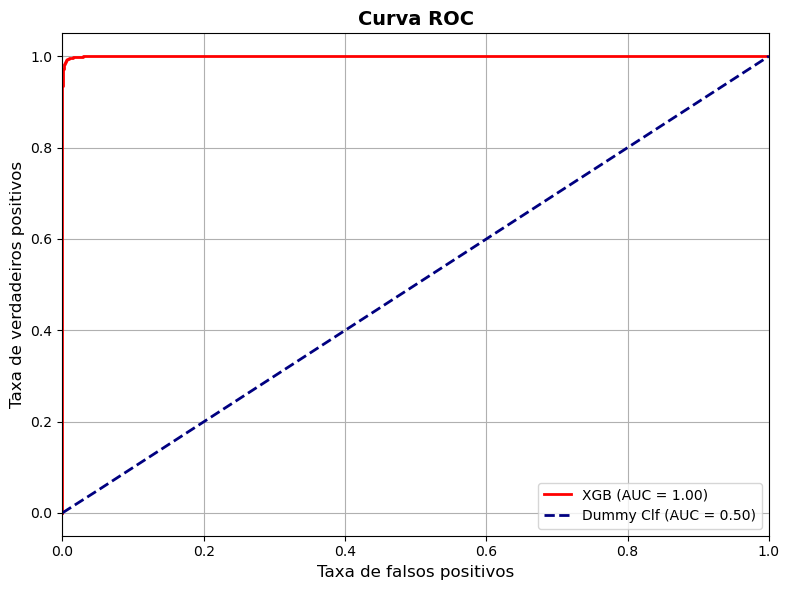

In [27]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipeline.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'XGB (AUC = {auc(fpr, tpr):.2f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.2f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# recall, precisão, f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

prec_dummy, prec_modelo  = precision_score(y_train, dummy.predict(X_train)), precision_score(y_train, pipeline.predict(X_train))

rec_dummy, rec_modelo = recall_score(y_train, dummy.predict(X_train)), recall_score(y_train, pipeline.predict(X_train))

f1_dummy, f1_modelo = f1_score(y_train, dummy.predict(X_train)), f1_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve precisão de {prec_dummy:.1%}, recall de {rec_dummy:.1%} e f1 de {f1_dummy:.1%}")
print(f"O meu XGB obteve precisão de {prec_modelo:.1%}, recall de {rec_modelo:.1%} e f1 de {f1_modelo:.1%}")

O modelo dummy obteve precisão de 4.8%, recall de 4.7% e f1 de 4.8%
O meu XGB obteve precisão de 99.8%, recall de 93.2% e f1 de 96.4%


In [ ]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'xgboost_pipeline_trained.joblib')